In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from snn import Network, Population, Projection, Port, Pack
from snn.model import IN, LIF, PSP

In [2]:
class Input(Network):
    def __init__(self, vec_times):
        super().__init__()
        self.vec_times = vec_times # n x t (eventlist)

    def build(self):
        self.vec = Population(IN(), len(self.vec_times), times=self.vec_times)
        
        super().build()
        return

In [3]:
class Linear(Network):
    def __init__(self, size=256):
        super().__init__()
        self.size = size
        self.input = Port()

    def build(self):
        # Populations
        self.layer = Population(LIF(), self.size)

        # Connections (fully connected)
        self.dense = Projection(self.input, self.layer, PSP(),
                                edges=[(i,j) for i,j in itertools.product(
                                    range(self.input.size),range(self.layer.size))],
                                weight=np.random.rand(self.input.size, self.layer.size).ravel())
        
        super().build()
        return

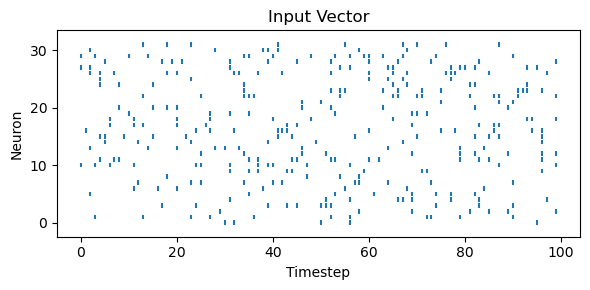

In [4]:
# Inputs
input_n = 32
input_t = 100
input_prob = 0.1

# Dense vector (just random 0s and 1s)
in_spikes = np.random.binomial(1, input_prob, (input_n, input_t))

# Sparse vector (only spike times)
in_n , in_t = np.where(in_spikes == 1)
in_times = [[] for _ in range(input_n)]
for n, t in zip(in_n, in_t):
    in_times[n].append(t)

# Visualize
plt.figure(figsize=(6, 3))
plt.eventplot(in_times, linelengths=0.8)
plt.xlabel('Timestep')
plt.ylabel('Neuron')
plt.title('Input Vector')
plt.tight_layout()

In [5]:
net = Network()

# Layers
net.i = Input(in_times)
net.ff = [Linear(64),
          Linear(128),
          Linear(10)]

# Connect them
net.connect(net.i.vec, net.ff[0].input)
net.connect(net.ff[0].layer, net.ff[1].input)
net.connect(net.ff[1].layer, net.ff[2].input)

info: adding network
info: adding list of networks


In [6]:
net.build()

info: building i
info: linking port as target
info: connection path layer does not exist (yet)
info: connection path layer does not exist (yet)
info: dependency resolved for input
info: building ff[0]
info: linking port as target
info: connection path layer does not exist (yet)
info: dependency resolved for input
info: building ff[1]
info: linking port as target
info: dependency resolved for input
info: building ff[2]
info: flattening network topology


In [7]:
print(net)

(port) ff[0].input <- (node) i.vec
(node) ff[0].layer
(edge) ff[0].dense: (port) ff[0].input <- (node) i.vec -> (node) ff[0].layer
(port) ff[1].input <- (node) ff[0].layer
(node) ff[1].layer
(edge) ff[1].dense: (port) ff[1].input <- (node) ff[0].layer -> (node) ff[1].layer
(port) ff[2].input <- (node) ff[1].layer
(node) ff[2].layer
(edge) ff[2].dense: (port) ff[2].input <- (node) ff[1].layer -> (node) ff[2].layer
(node) i.vec


In [8]:
# Can take a look at the weights (initialized randomly)
net.ff[1].dense.weight

array([0.53483589, 0.75426665, 0.03273902, ..., 0.00485262, 0.51497969,
       0.96332502])

In [9]:
# Network size should be this
# 32 + 64 + 128 + 10 = 234
print(net._graph.number_of_nodes())
# 32x64 + 64x128 + 128x10 = 11520
print(net._graph.number_of_edges())

234
11520


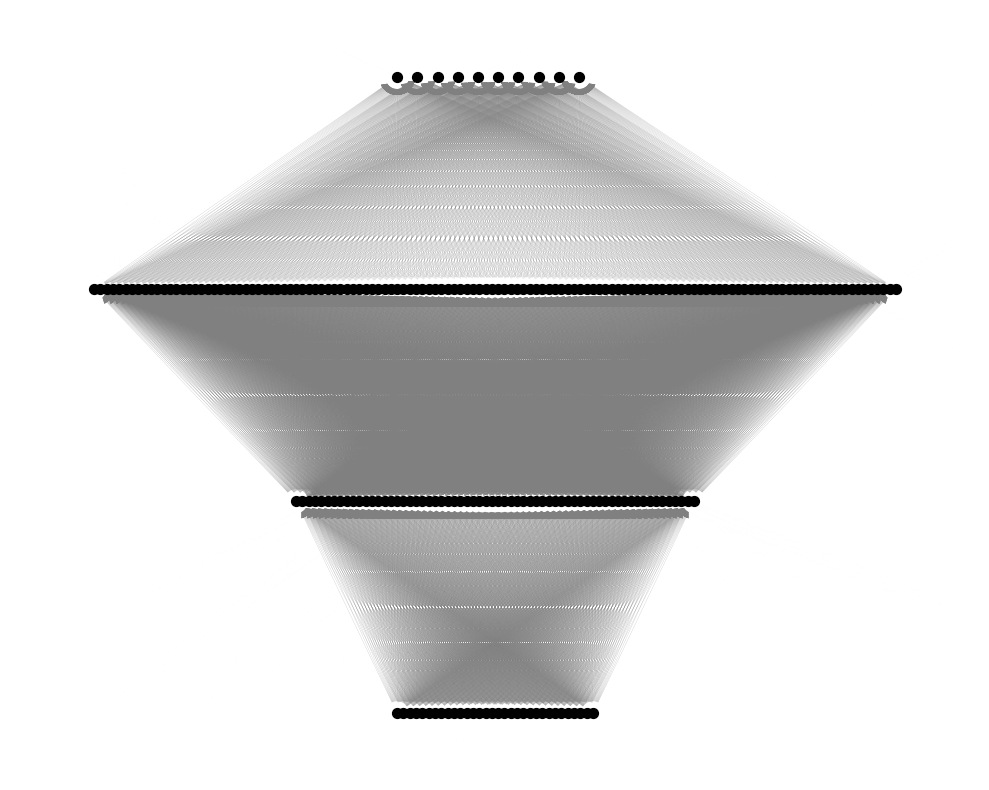

In [10]:
# Modify the positions a bit for the visualization
pos = nx.circular_layout(net._graph)
for i in range(len(net.i.vec)):
    pos[net.i.vec[i].name][0] = 1.0 * i / len(net.i.vec) - 0.5
    pos[net.i.vec[i].name][1] = 0.0
width = [2.0, 4.0, 1.0]
for l in range(len(net.ff)):
    for i in range(len(net.ff[l].layer)):
        pos[net.ff[l].layer[i].name][0] = width[l] * i / len(net.ff[l].layer) - width[l] / 2
        pos[net.ff[l].layer[i].name][1] = 1.0 + l

# Visualize
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(net._graph, pos, node_size=50, node_color='black')
nx.draw_networkx_edges(net._graph, pos, edge_color='gray', width=0.1)

plt.axis('off')
plt.tight_layout()